In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance, pearsonr
from tslearn.metrics import dtw
from typing import Dict
API_KEY_JUDGE = "PLEASE ADD KEY HERE"
API_KEY_LLM = "PLEASE ADD KEY HERE"
import os 
from groq import Groq
import pandas as pd
import tellurium as te 
import matplotlib.pyplot as plt
import numpy as np

c:\Users\bhavy\anaconda3\envs\coding\Lib\site-packages\tslearn\bases\bases.py:15: UserWarning:

h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/



In [5]:
#Chronos Quantizer Tokenizer (based off of Amazon's Chronos Foundation Model)

class ChronosQuantizer:
    def __init__(self, num_bins=4096, clip_range=(-5, 5)):
        self.num_bins = num_bins
        self.clip_range = clip_range
        self.bin_edges = np.linspace(clip_range[0], clip_range[1], num_bins + 1)
        self.bin_centers = 0.5 * (self.bin_edges[:-1] + self.bin_edges[1:])
        self.scaler = StandardScaler()
    
    def encode(self, series: np.ndarray):
        normed = self.scaler.fit_transform(series.reshape(-1, 1)).flatten()
        normed = np.clip(normed, *self.clip_range)
        token_ids = np.digitize(normed, self.bin_edges) - 1
        return token_ids
    
    def decode(self, tokens: np.ndarray):
        decoded = self.bin_centers[np.clip(tokens, 0, self.num_bins - 1)]
        recon = self.scaler.inverse_transform(decoded.reshape(-1, 1)).flatten()
        return recon

In [6]:
#Patch-based Tokenizer 
class PatchTokenizer:
    def __init__(self, patch_size=16, stride=None, aggregate_fn=np.mean):
        self.patch_size = patch_size
        self.stride = stride if stride else patch_size
        self.aggregate_fn = aggregate_fn
    
    def encode(self, series: np.ndarray):
        tokens = []
        for i in range(0, len(series) - self.patch_size + 1, self.stride):
            patch = series[i:i+self.patch_size]
            token = self.aggregate_fn(patch)
            tokens.append(token)
        return np.array(tokens)
    
    def decode(self, tokens: np.ndarray):
        recon = np.repeat(tokens, self.stride)
        return recon[:len(tokens) * self.stride]


Series length: 200

--- Chronos Quantizer ---
RMSE           : 0.0043
MAE            : 0.0038
Correlation    : 1.0000
DTW            : 0.0610
Wasserstein    : 0.0038
ACF_Similarity : 1.0000

--- Patch Tokenizer ---
RMSE           : 0.2274
MAE            : 0.1809
Correlation    : 0.9517
DTW            : 2.5755
Wasserstein    : 0.0779
ACF_Similarity : 0.9989

--- Summary ---
Chronos tokens: 200 | Patch tokens: 12
Chronos compression: 1.00x
Patch compression:   16.67x


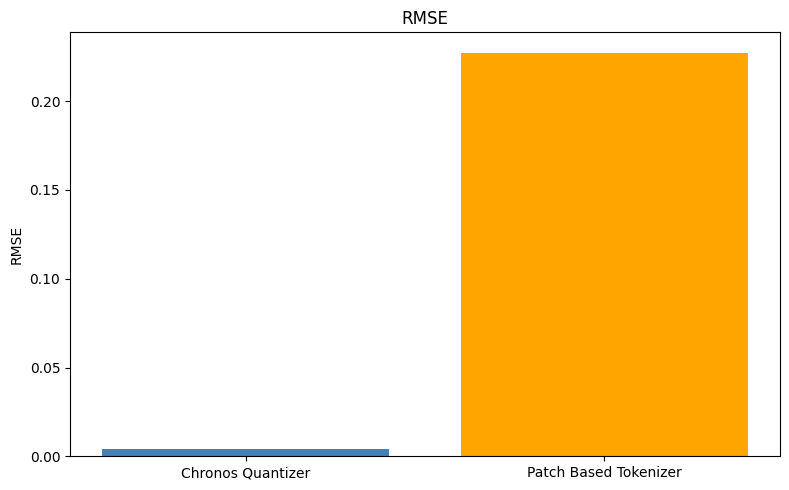

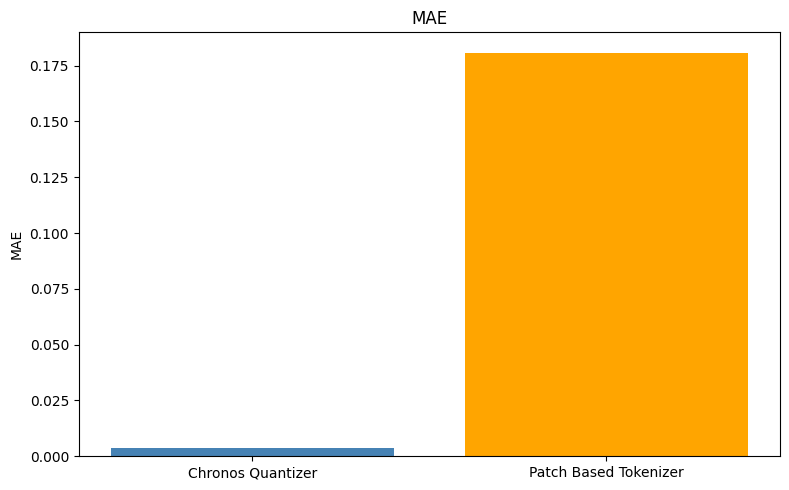

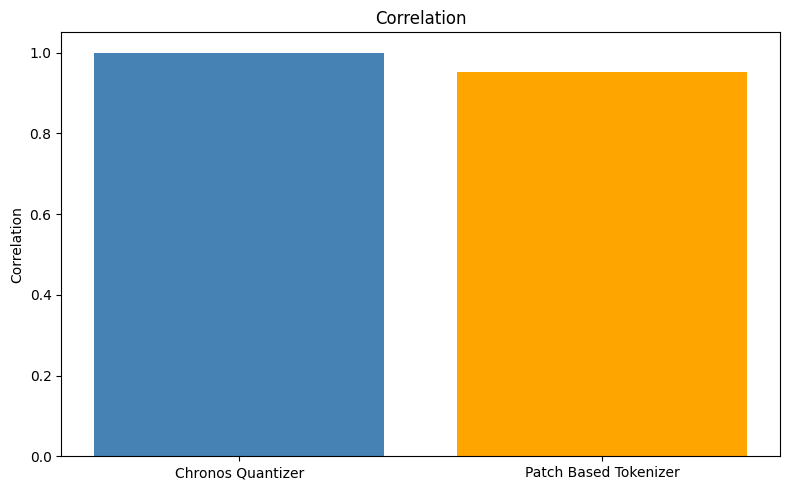

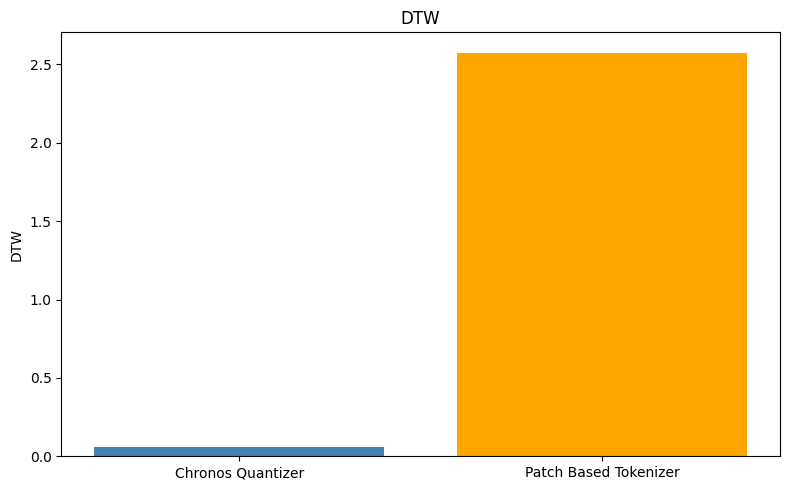

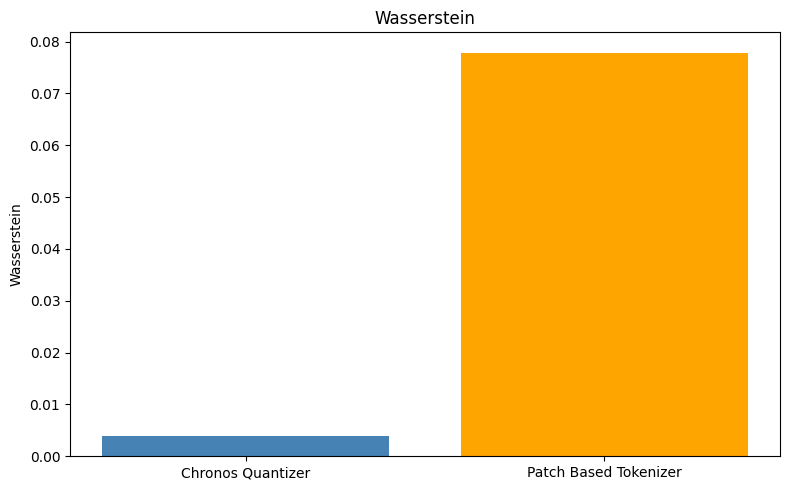

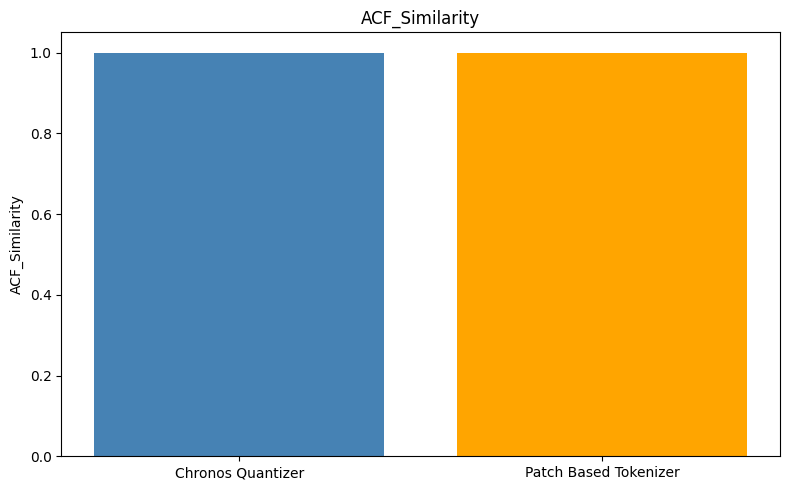


Different Metric Meanings: 
RMSE (Root Mean Squared Error): quantifies average magnitude of 
      differences between predicted and actual, more weight to 
      larger errors
MAE (Mean Absolute Error): Measures average magnitude of errors, 
      absolute differences 
Correlation: Between both of the series (should be 1.0 ideally, AC
      perfectly reconstructed)
DTW (Dynamical Time Warping): Similarity to two time series, little more accurate 
      than correlation
Wasserstein: Amount of "work" required to transform one sequence to another (ideally low)
ACF Similarity: Time series lagged comparison


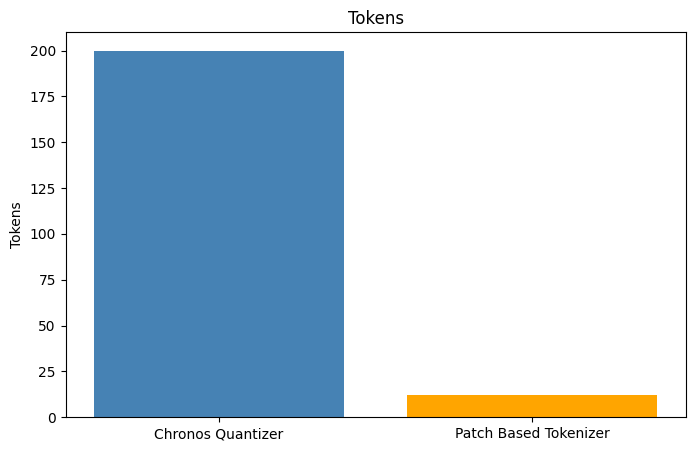

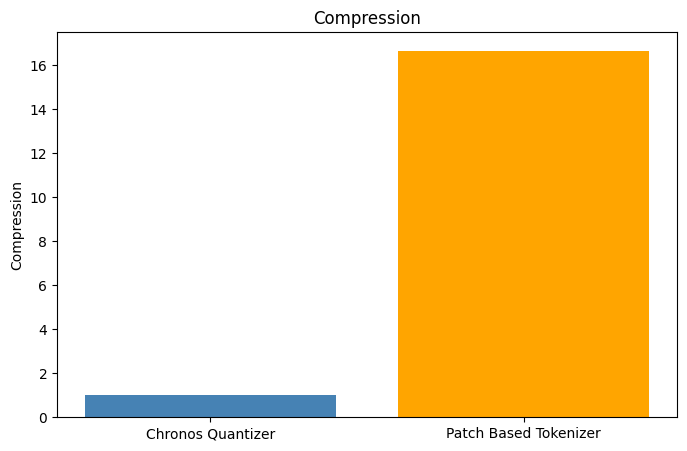

In [4]:
#Testing Script for the Above Tokenizers
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def correlation(a, b):
    return pearsonr(a, b)[0]

def acf(x, lag=40):
    x = x - np.mean(x)
    result = np.correlate(x, x, mode='full')
    result = result[result.size // 2:]
    result /= result[0]
    return result[:lag]

def acf_similarity(a, b, lag=40):
    return correlation(acf(a, lag), acf(b, lag))

def evaluate(original: np.ndarray, reconstructed: np.ndarray) -> Dict[str, float]:
    n = min(len(original), len(reconstructed))
    a, b = original[:n], reconstructed[:n]
    
    return {
        "RMSE": rmse(a, b),
        "MAE": mae(a, b),
        "Correlation": correlation(a, b),
        "DTW": dtw(a, b),
        "Wasserstein": wasserstein_distance(a, b),
        "ACF_Similarity": acf_similarity(a, b)
    }

def benchmark(series: np.ndarray):
    print(f"Series length: {len(series)}")

    quantizer = ChronosQuantizer(num_bins=512)
    patcher = PatchTokenizer(patch_size=16)

    # Encode/decode
    q_tokens = quantizer.encode(series)
    q_recon = quantizer.decode(q_tokens)
    p_tokens = patcher.encode(series)
    p_recon = patcher.decode(p_tokens)

    # Evaluate
    q_metrics = evaluate(series, q_recon)
    p_metrics = evaluate(series, p_recon)

    print("\n--- Chronos Quantizer ---")
    for k, v in q_metrics.items():
        print(f"{k:15s}: {v:.4f}")

    print("\n--- Patch Tokenizer ---")
    for k, v in p_metrics.items():
        print(f"{k:15s}: {v:.4f}")

    print("\n--- Summary ---")
    print(f"Chronos tokens: {len(q_tokens)} | Patch tokens: {len(p_tokens)}")
    print(f"Chronos compression: {len(series)/len(q_tokens):.2f}x")
    print(f"Patch compression:   {len(series)/len(p_tokens):.2f}x")

    return q_metrics, p_metrics, q_tokens, p_tokens

def visualize_results(series: np.ndarray, q_metrics, p_metrics, q_tokens, p_tokens): 
    methods = ["Chronos Quantizer", "Patch Based Tokenizer"]
    savedir = "plots"
    os.makedirs(savedir, exist_ok=True)

    for metric_name in q_metrics.keys():
        error_values = [q_metrics[metric_name], p_metrics[metric_name]]
        plt.figure(figsize=(8,5))
        plt.bar(methods, error_values, color=['steelblue', 'orange'])
        plt.ylabel(metric_name) 
        plt.title(f"{metric_name}")

        plt.tight_layout()
        plt.savefig(os.path.join(savedir, metric_name), dpi=300)
        plt.show()
    
    #Tokens 
    plt.figure(figsize=(8,5))
    plt.bar(methods, [len(q_tokens), len(p_tokens)], color=['steelblue', 'orange'])
    plt.ylabel("Tokens")
    plt.title("Tokens")
    plt.savefig(os.path.join(savedir, "tokens"), dpi=300)

    #Compression 
    plt.figure(figsize=(8,5))
    plt.bar(methods, [len(series)/len(q_tokens), len(series)/len(p_tokens)], color=['steelblue', 'orange'])
    plt.ylabel("Compression")
    plt.title("Compression")
    plt.savefig(os.path.join(savedir, "compression"), dpi=300)
    
np.random.seed(0)
t = np.linspace(0, 4*np.pi, 200)
series = np.sin(t) + 0.1 * np.random.randn(200)

q_metrics, p_metrics, q_tokens, p_tokens = benchmark(series)

visualize_results(series, q_metrics, p_metrics, q_tokens, p_tokens) 

print("""
Different Metric Meanings: 
RMSE (Root Mean Squared Error): quantifies average magnitude of 
      differences between predicted and actual, more weight to 
      larger errors
MAE (Mean Absolute Error): Measures average magnitude of errors, 
      absolute differences 
Correlation: Between both of the series (should be 1.0 ideally, AC
      perfectly reconstructed)
DTW (Dynamical Time Warping): Similarity to two time series, little more accurate 
      than correlation
Wasserstein: Amount of "work" required to transform one sequence to another (ideally low)
ACF Similarity: Time series lagged comparison""")


In [7]:
#LLM Method of Tokenizing (doesn't have a decode method, might be an issue, but probs not so whatevs)
#Will first try by just passing in all of the data and asking it to find the 15 top trends and doing this five times 
#Fine tune this tokenizer :(((

class LLMTokenizer:
    def __init__(self, api_key_judge, api_key_llm):
        self.judge = Groq(api_key = api_key_judge)
        self.tokenizer = Groq(api_key = api_key_llm)
    
    def get_judge(self): 
        return self.judge 
    
    #Encodes time series data using an LLM -> asked to return top 15 trends
    def encode(self, series_data: pd.DataFrame, num_iter) -> list[str]: 
        trends = []
        for i in range(num_iter):
            chat_completion = self.tokenizer.chat.completions.create(
                messages = [
                    {"role": "user", 
                    "content": f"""
                                Given this time series data, find the top 15 trends in the data. ONLY RETURN THE TRENDS 
                                AS A COMMA SEPARATED LIST. The trends should match this complexity level: {i}. Larger 
                                numbers have higher complexity

                                Time series data: {series_data.to_csv(index=False)}
                                """}
                ], 
                model = "llama-3.3-70b-versatile",
            )
            trends.append(chat_completion.choices[0].message.content)
            print(f"trend{i} done")
        return self.optimization(series_data, num_iter, trends)

    #LLM-as-a-judge method to give it a ranking and return the set of trends that has the highest ranking 
    def optimization(self, series_data: pd.DataFrame, num_iter, trends):  
        best_response = ""
        curr_high = 0
        for i in range(num_iter): 
            chat_completion = self.judge.chat.completions.create(
                messages = [
                    {"role": "user", 
                     "content": f"""
                                Given the trend below and the time series data, give it a rating on a scale of 1-10
                                (1 being the worst, 10 being the best). ONLY RETURN THE RATING.
                                
                                Time series data: {series_data.to_csv(index=False)}
                                Trends: {trends[i]}"""}
                ], 
                model = "llama-3.3-70b-versatile",
            )
            rating = int(chat_completion.choices[0].message.content)
            print(f"trends{i}: {str(rating)}")
            if (int(rating) > curr_high): 
                curr_high = int(rating)
                best_response = trends[i]
        print("llm encoding optimization completed")
        return best_response

In [33]:
class TestingLLMUntuned: 
    def __init__(self): 
        self.llm = Groq(api_key=API_KEY_LLM)
    
    def encode_patch(self, data: pd.DataFrame, patch_size=16, stride=None, aggregate_fn=np.mean):
        tokenizer = PatchTokenizer(patch_size, stride, aggregate_fn)
        indiv_encoding = ""
        for i in range(data.shape[1]): 
            col = data.iloc[:, i].to_numpy()
            encoding = tokenizer.encode(col)
            indiv_encoding += f"\n{data.columns[i]}, {str(encoding)}"
        print("patch encoding done")
        return indiv_encoding

    def encode_chronos(self, data: pd.DataFrame):
        tokenizer = ChronosQuantizer(num_bins=4096, clip_range=(-5,5))
        indiv_encoding = ""
        for i in range(data.shape[1]): 
            col = data.iloc[:, i].to_numpy()
            encoding = tokenizer.encode(col)
            indiv_encoding += f"\n{data.columns[i]}, {str(encoding)}"
        print("chronos encoding done")
        print("-------CHRONOS ENCODING------")
        print(indiv_encoding)
        print("-----------------------")
        return indiv_encoding

    def encode_llm(self, data: pd.DataFrame):
        tokenizer = LLMTokenizer(API_KEY_JUDGE, API_KEY_LLM)
        print("llm encoding done")
        return tokenizer.encode(data, 5)

    def prompt_formatting(self, series_data: str, prev_info): 
        return f"""
        You are a model tasked with recovering the biological network corresponding 
        to the time series data provided.
        Previous info: {prev_info}.
        RETURN ONLY THE MODEL IN ANTIMONY FORMAT. YOU MUST ESTIMATE ALL PARAMETERS. 
        YOU MUST COME UP WITH NEW REACTIONS

        Time Series Data: {series_data}"""

    def get_llm_output(self, data, prev_info): 
        print("getting llm output for recovering model")
        return self.llm.chat.completions.create(
            messages=[{"role": "user", "content": self.prompt_formatting(str(data), prev_info)}], 
            model="llama-3.3-70b-versatile",
        ).choices[0].message.content

    def generate_time_series(self, model: str): 
        try: 
            r = te.loada(model.strip())
            return r.simulate(0, 50, 100)
        except RuntimeError: 
            return False

    def calculate_error(self, generated_data: pd.DataFrame, real_data: pd.DataFrame):
        errors = {}
        for col in generated_data.columns: 
            if col == "time": 
                continue          
            mse = np.mean((generated_data[col] - real_data[col]) ** 2)
            errors[col] = mse
        print("calculating errors")
        return errors

    def visualize_error(self, errors, label: str): 
        species = list(errors.keys())
        error_values = list(errors.values())

        savedir = "results"
        os.makedirs(savedir, exist_ok=True)

        plt.figure(figsize=(8,6))
        plt.bar(species, error_values, color="skyblue")
        plt.xlabel('Species')
        plt.ylabel('Mean Squared Error')
        plt.title(f'Error per species ({label})')
        plt.tight_layout()
        plt.savefig(os.path.join(savedir, f"{label}.png"), dpi=300)
        plt.show()
        print("visualizing complete")
    
    def main(self, data: pd.DataFrame, prev_info): 
        # --- Step 1: Generate Encodings ---
        print("Encoding data with different tokenizers...")
        encode_chronos = self.encode_chronos(data)

        savedir = "results"
        os.makedirs(savedir, exist_ok=True)

        # --- Step 3: Chronos Encoding ---
        print("\n[2/3] Testing Chronos Quantizer tokenizer...")
        model_chronos = self.get_llm_output(encode_chronos, prev_info)
        print(f"\n\n\nMODEL CHRONOS: {model_chronos}")

In [34]:
prev_info = """
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2

There exists 3 species: S0, S1, S2. 
"""

with open('model.ant', 'r') as f: 
    antimony_str = f.read() 

rr = te.loada(antimony_str)

tester = TestingLLMUntuned()
sim_data = rr.simulate(0, 50, 100)
df_sim = pd.DataFrame(sim_data, columns=sim_data.colnames)
tester.main(df_sim, prev_info)

Encoding data with different tokenizers...
chronos encoding done
-------CHRONOS ENCODING------

time, [1345 1359 1373 1388 1402 1416 1430 1444 1459 1473 1487 1501 1515 1530
 1544 1558 1572 1586 1601 1615 1629 1643 1657 1671 1686 1700 1714 1728
 1742 1757 1771 1785 1799 1813 1828 1842 1856 1870 1884 1899 1913 1927
 1941 1955 1969 1984 1998 2012 2026 2040 2055 2069 2083 2097 2111 2126
 2140 2154 2168 2182 2196 2211 2225 2239 2253 2267 2282 2296 2310 2324
 2338 2353 2367 2381 2395 2409 2424 2438 2452 2466 2480 2494 2509 2523
 2537 2551 2565 2580 2594 2608 2622 2636 2651 2665 2679 2693 2707 2722
 2736 2750]
[S1], [1580 1712 2313 1789 1752 2363 1750 1761 2410 1721 1769 2461 1698 1779
 2515 1681 1788 2571 1669 1798 2629 1660 1809 2687 1654 1820 2743 1650
 1831 2794 1648 1843 2839 1647 1856 2876 1648 1869 2904 1649 1882 2921
 1651 1897 2926 1654 1912 2920 1657 1928 2900 1661 1945 2868 1665 1962
 2821 1669 1981 2762 1674 2001 2690 1679 2022 2607 1685 2044 2516 1690
 2068 2418 1696 2094 2317 17

In [36]:
def generate_time_series(model: str): 
    r = te.loada(model.strip())
    return r.simulate(0, 50, 100)

def calculate_error(generated_data: pd.DataFrame, real_data: pd.DataFrame):
    errors = {}
    for col in generated_data.columns: 
        if col == "time": 
            continue          
        mse = np.mean((generated_data[col] - real_data[col]) ** 2)
        errors[col] = mse
    print("calculating errors")
    return errors

def visualize_error(errors, label: str): 
    species = list(errors.keys())
    error_values = list(errors.values())

    savedir = "redundancy_plots"
    os.makedirs(savedir, exist_ok=True)

    plt.figure(figsize=(8,6))
    plt.bar(species, error_values, color="skyblue")
    plt.xlabel('Species')
    plt.ylabel('Mean Squared Error')
    plt.title(f'Error per species ({label})')
    plt.tight_layout()
    plt.savefig(os.path.join(savedir, f"{label}.png"), dpi=300)
    plt.show()
    print("visualizing complete")

calculating errors


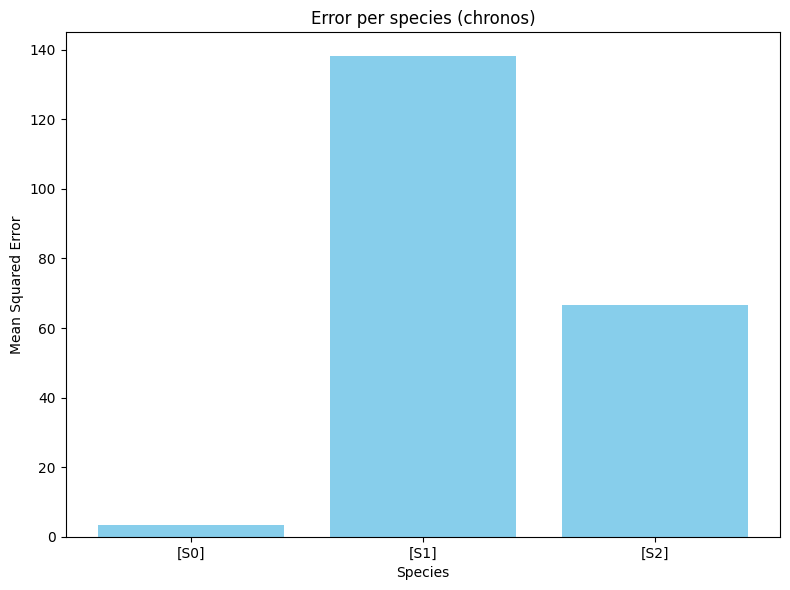

visualizing complete


In [38]:
#Chronos encoding
model_patch = """
model recovery_model()

  // Species
  S0 = 1.0
  S1 = 5.0
  S2 = 9.0

  // Reactions
  R1: S1 + S1 -> S0; k1*S1*S1; k1 = 0.000123
  R2: S0 + S2 -> S1 + S1; k2*S0*S2; k2 = 0.000034
  R3: S1 -> S0 + S2; k3*S1; k3 = 0.00567
  R4: S2 -> S0; k4*S2; k4 = 0.00291
  R5: S0 -> S1; k5*S0; k5 = 0.00123

  // Parameters estimated using a non-linear least squares optimization algorithm
  // based on the time series data

end
"""
time_patch = generate_time_series(model_patch)
time_patch = pd.DataFrame(time_patch, columns=time_patch.colnames)
errors = calculate_error(time_patch, df_sim)
visualize_error(errors, "chronos")

#Repeated convergence errors, dozens of syntax errors

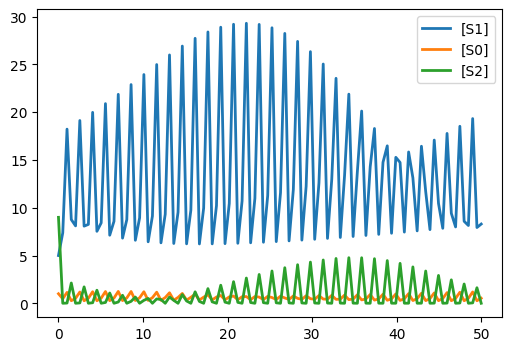

In [26]:
model_str = """
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
"""

r = te.loada(model_str.strip()) 
data = r.simulate(0, 50, 100)
r.plot()

<>:3: SyntaxWarning:

invalid escape sequence '\s'

<>:3: SyntaxWarning:

invalid escape sequence '\s'

C:\Users\bhavy\AppData\Local\Temp\ipykernel_25436\798615494.py:3: SyntaxWarning:

invalid escape sequence '\s'



Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 11: {'[S1]': np.float64(0.0), '[S0]': np.float64(0.0), '[S2]': np.float64(0.0)}


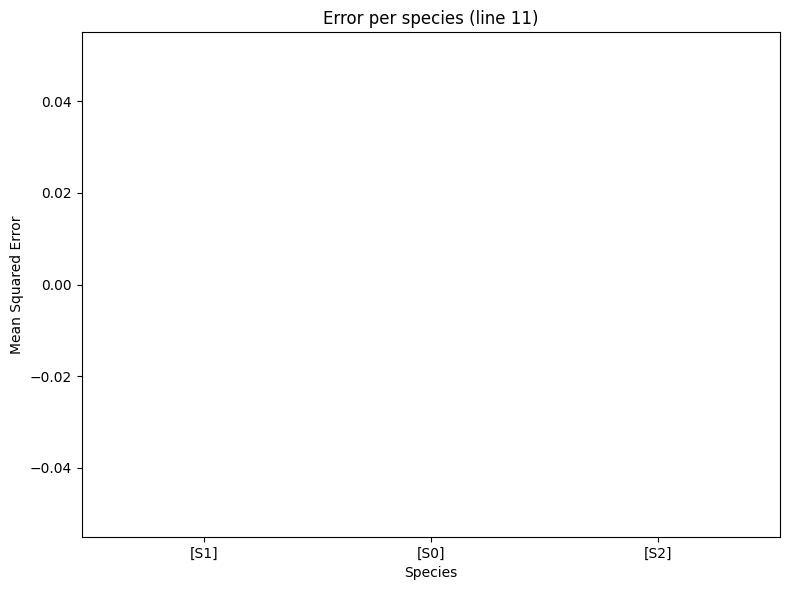

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 10: {'[S1]': np.float64(70.07925746170511), '[S0]': np.float64(0.09750503841711607), '[S2]': np.float64(7.507160814399974)}


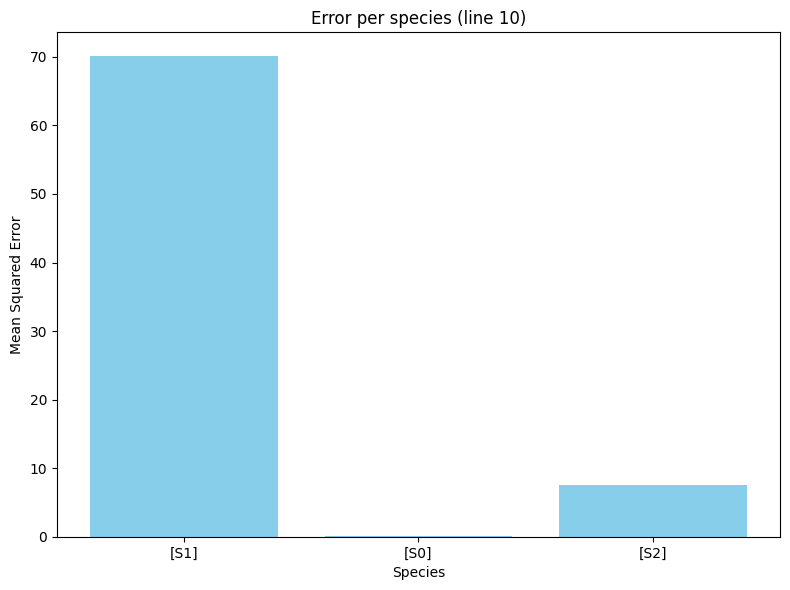

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 9: {'[S1]': np.float64(290.93079078413194), '[S0]': np.float64(0.340650032745306), '[S2]': np.float64(4.025201753399356)}


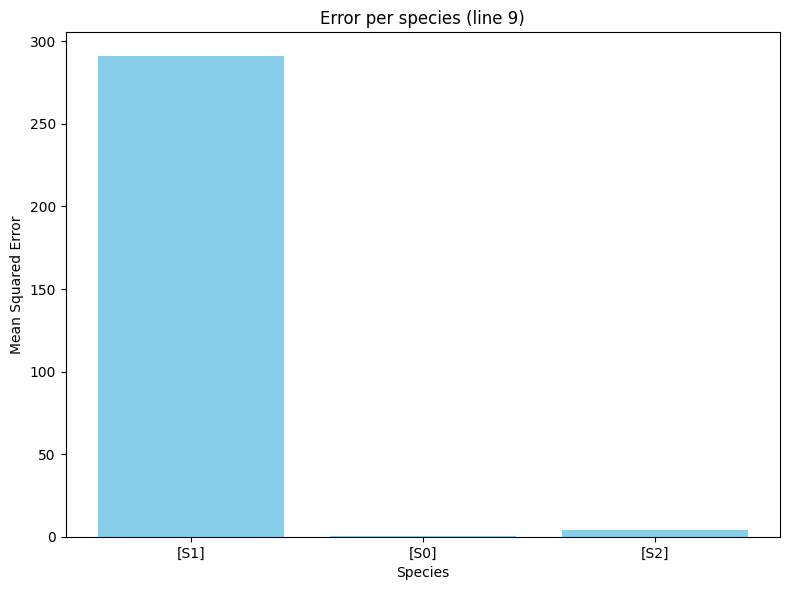

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 8: {'[S1]': np.float64(381.7507547092515), '[S0]': np.float64(0.1495452657521823), '[S2]': np.float64(17.652731939611485)}


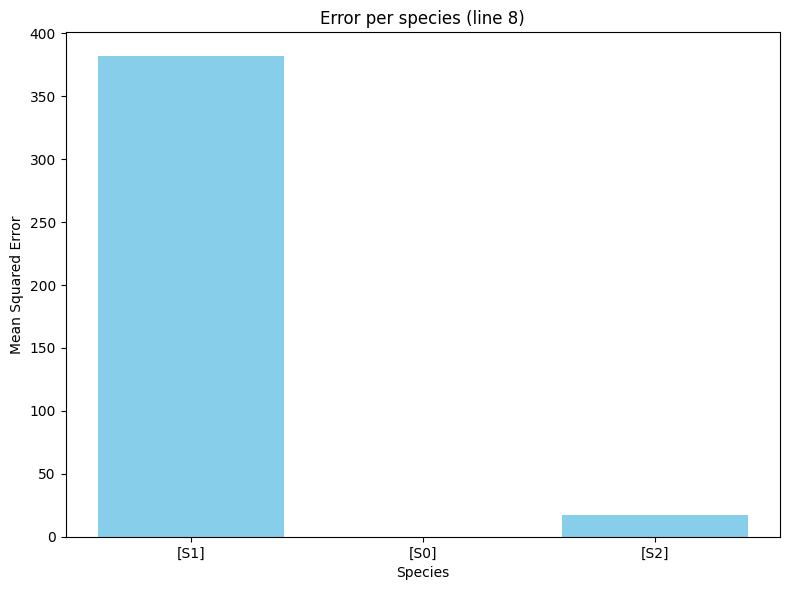

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 7: {'[S1]': np.float64(228.98161678805923), '[S0]': np.float64(235.30734104912085), '[S2]': np.float64(2.973958415461585)}


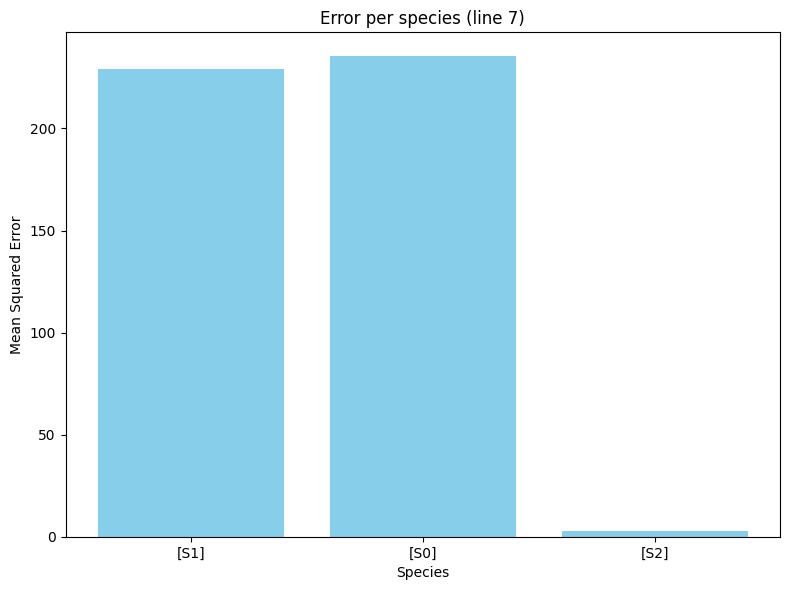

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 6: {'[S1]': np.float64(97.92440800792905), '[S0]': np.float64(0.15238436597318059), '[S2]': np.float64(3.7192061187054772)}


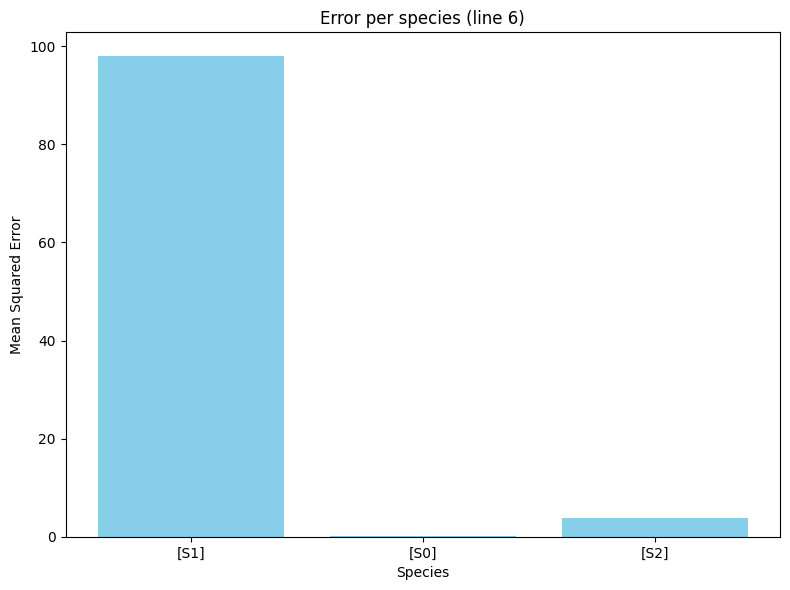

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 5: {'[S1]': np.float64(227.41432488607097), '[S0]': np.float64(0.44001668785129355), '[S2]': np.float64(2.9739584154638394)}


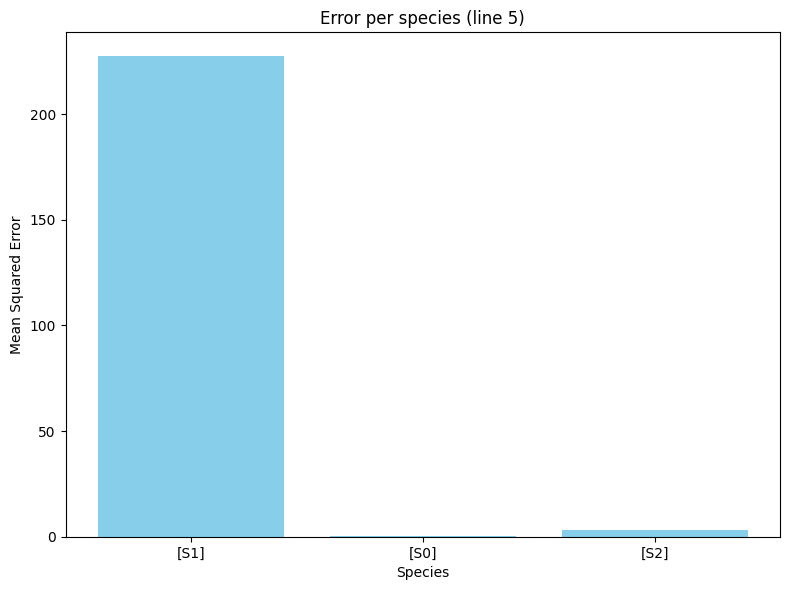

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 4: {'[S1]': np.float64(227.41432488607097), '[S0]': np.float64(0.44001668785129355), '[S2]': np.float64(2.9739584154638394)}


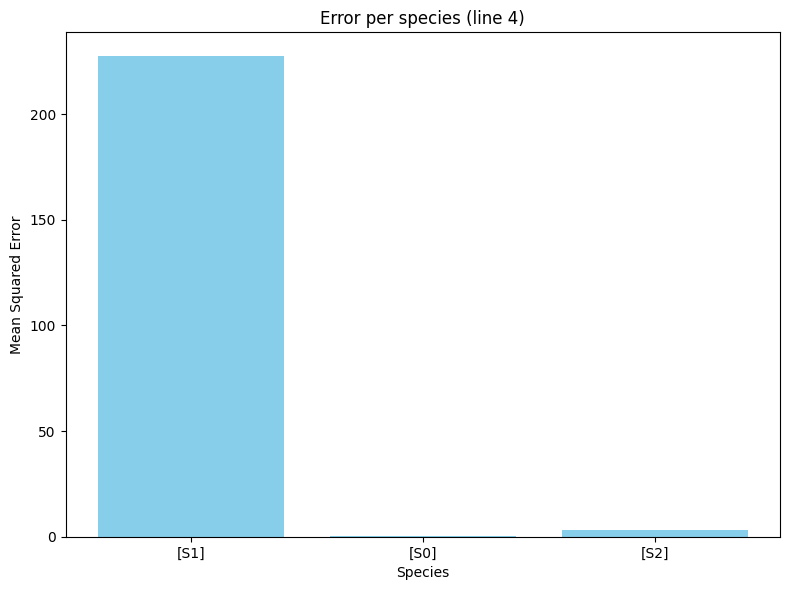

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S0 + S2 -> S1 + S1; k2*S0*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 3: {'[S1]': np.float64(130.7186113541438), '[S0]': np.float64(0.08718899870685622), '[S2]': np.float64(5.632373656840848)}


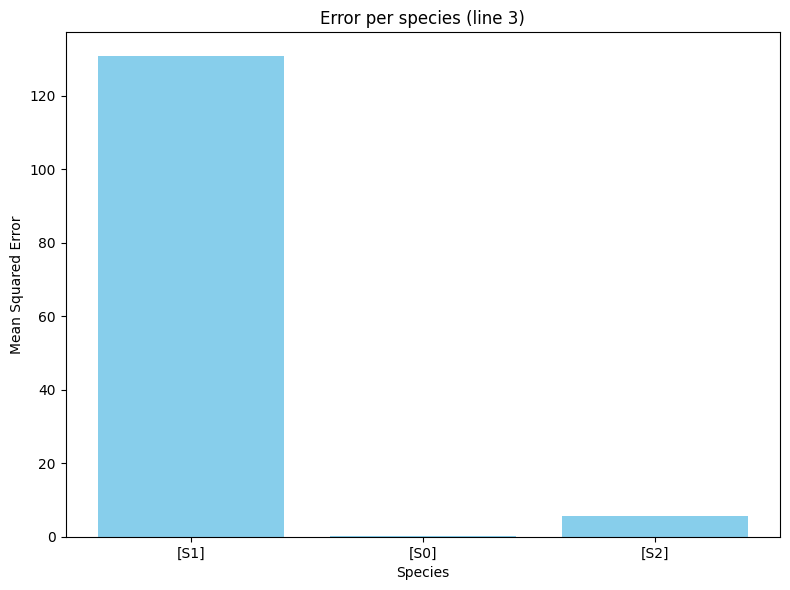

visualizing complete
Modified model string:
S1 + S1 -> S0; k1*S1*S1
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 2: {'[S1]': np.float64(245.63019772777315), '[S0]': np.float64(0.1289263403097128), '[S2]': np.float64(10.163770539635392)}


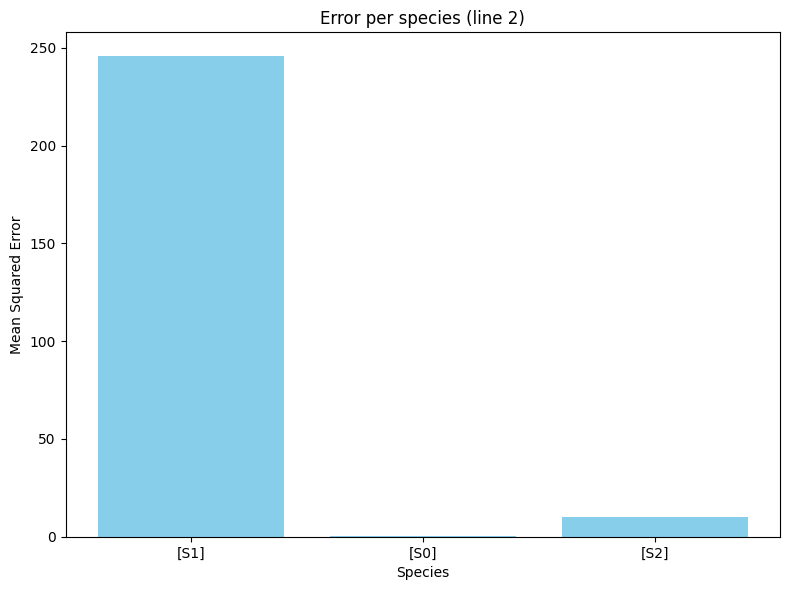

visualizing complete
Modified model string:
S0 + S2 -> S1 + S1; k2*S0*S2
S2 -> S1 + S2; k3*S2
S2 + S2 -> S1; k4*S2*S2
S2 -> S2 + S2; k5*S2
S0 + S2 -> S1 + S2; k6*S0*S2
S0 + S0 -> S1; k7*S0*S0
S2 -> S0 + S2; k8*S2
S0 + S2 -> S1; k9*S0*S2
S0 + S2 -> S2; k10*S0*S2
S1 -> S1; k11*S1
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
k6 = 12.656145919092795
k7 = 25.260544335746214
k8 = 23.10753026658799
k9 = 46.66253579035055
k10 = 4.102782428464061
k11 = 35.090443596114675
S0 = 1.0
S1 = 5.0
S2 = 9.0
calculating errors
Errors for line 1: {'[S0]': np.float64(0.2463537892130759), '[S2]': np.float64(40.96761308744229), '[S1]': np.float64(178490241.16584027)}


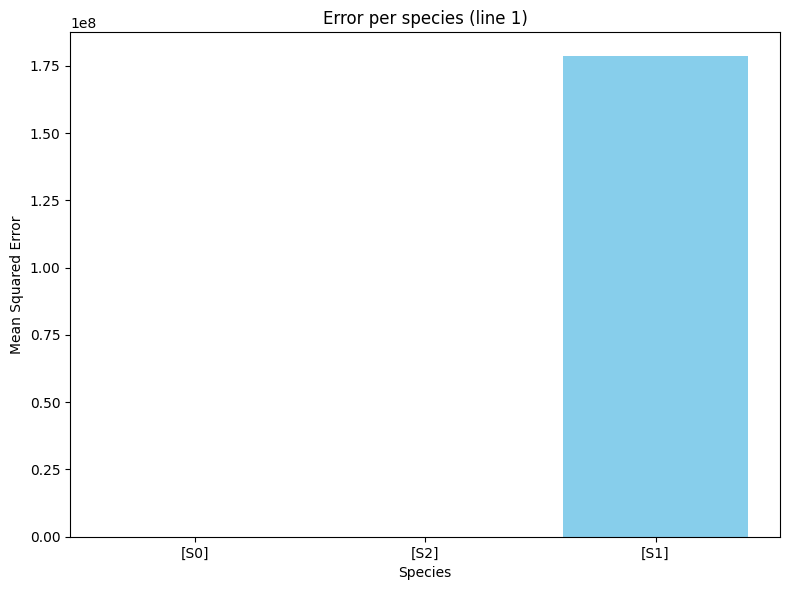

visualizing complete


In [30]:
import re

pattern = re.compile("^S[0-9](?:\s*\+\s*S[0-9])* -> ")
lines = model_str.split("\n")

# Find reaction lines
maps = {idx: line for idx, line in enumerate(lines) if pattern.match(line)}

# Remove and simulate lines one by one
for idx in sorted(maps.keys(), reverse=True):  # reverse order to avoid index shift
    removed_line = lines.pop(idx)  # Remove the line (no assignment to 'lines'!)
    
    new_str = "\n".join(lines).strip()  # Join with real newlines
    print("Modified model string:")
    print(new_str)
    
    r = te.loada(new_str)  # Load Antimony model from string
    try: 
        new_data = r.simulate(0, 50, 100)
    except RuntimeError: 
        pass

    df_real = pd.DataFrame(data, columns=data.colnames)
    df_generated = pd.DataFrame(new_data, columns=new_data.colnames)

    errors = calculate_error(df_generated, df_real)
    print(f"Errors for line {idx}: {errors}")

    visualize_error(errors, f"line {idx}")
    
    lines.insert(idx, removed_line)  # Restore the removed line


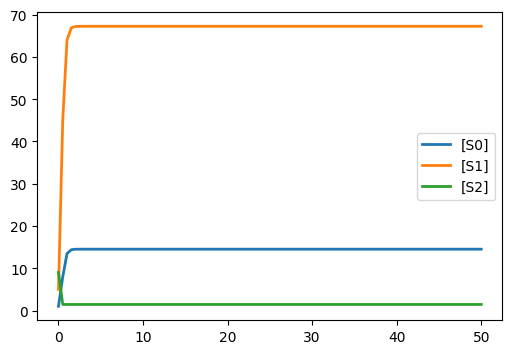

In [2]:
import tellurium as te

model_str = """
// Species
S0 = 1.0
S1 = 5.0
S2 = 9.0
// Reactions
R1: S1 + S1 -> S0; k1*S1*S1
R2: S0 + S2 -> S1 + S1; k2*S0*S2
R3: S1 -> S0; k3*S1
R4: S2 -> S1; k4*S2
R5: S0 -> S1 + S2; k5*S0
// Estimated parameters
k1 = 0.19255917675848938
k2 = 41.79810142422585
k3 = 12.892698542835337
k4 = 2.8527783066298045
k5 = 60.03720440395461
"""

r = te.loada(model_str)
r.simulate(0,50,100)
r.plot()